In [42]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [43]:
download_base = Path('../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

'releases/20260415/manifest.json'

In [44]:
datasets = ['Zhuang-ABCA-1']
example_section = {'Zhuang-ABCA-1': 'Zhuang-ABCA-1.079'}

In [45]:
cell = {}

for d in datasets :

    cell[d] = abc_cache.get_metadata_dataframe(
        directory=d,
        file_name='cell_metadata',
        dtype={"cell_label": str}
    )
    cell[d].set_index('cell_label', inplace=True)
    
    sdf = cell[d].groupby('brain_section_label')
    
    print(d,":","Number of cells = ", len(cell[d]), ", ", "Number of sections =", len(sdf))

Zhuang-ABCA-1 : Number of cells =  2846908 ,  Number of sections = 147


In [46]:
cell[datasets[0]]

,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id
cell_label,,,,,,,,,,,,,
182941331246012878296807398333956011710,Zhuang-ABCA-1.089,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,704,0.682522,3.366483,7.829530,0.969933,0.718088,True,79bda012-4dd4-43d7-8f66-1f29997f6780
221260934538535633595532020856387724686,Zhuang-ABCA-1.089,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5243,0.667690,3.442241,7.829530,0.850554,0.850554,True,2f0b3159-2766-4f9e-a8cd-8dd16bae05fa
22228792606814781533240955623030943708,Zhuang-ABCA-1.089,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,0.638731,3.474328,7.829530,0.888285,0.649581,True,fe1f5f73-5afb-4e51-b4f0-cf6690257086
272043042552227961220474294517855477150,Zhuang-ABCA-1.089,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,0.653425,3.433218,7.829530,0.900000,0.607080,True,a13e1c1c-9828-4d3b-9aae-e2ab055a39ad
110116287883089187971185374239350249328,Zhuang-ABCA-1.089,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5254,0.623896,3.513574,7.829530,0.999978,0.689511,True,add02bc8-456b-486c-9f13-db578c62cc5a
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94310525370042131911495836073267655162,Zhuang-ABCA-1.110,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5255,0.997247,3.823236,9.717769,0.971385,0.943456,True,3e178fe9-3440-4cf1-ab79-2192d25e3d02
298798481479578578007190103666214714353,Zhuang-ABCA-1.110,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,1.043871,3.706231,9.717769,0.956377,0.905493,True,22cfcaf3-0c26-41b7-ab14-f76398fd18a4
330756942354980576352210203729462562749,Zhuang-ABCA-1.110,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5261,1.037680,3.759890,9.717769,0.811520,0.788901,True,bc4eb252-c3fd-4ba0-9739-70eff08b29fe


In [47]:
slice_counts = cell['Zhuang-ABCA-1']['brain_section_label'].value_counts()
print(slice_counts.head(10))

brain_section_label
Zhuang-ABCA-1.080    37068
Zhuang-ABCA-1.078    34735
Zhuang-ABCA-1.090    32633
Zhuang-ABCA-1.088    32314
Zhuang-ABCA-1.085    32047
Zhuang-ABCA-1.079    31982
Zhuang-ABCA-1.064    31253
Zhuang-ABCA-1.077    30864
Zhuang-ABCA-1.092    30741
Zhuang-ABCA-1.102    30709
Name: count, dtype: int64


In [48]:
# abc_cache method
#methods = [m for m in dir(abc_cache) if 'data' in m or 'get' in m]
#print(methods)

In [49]:
#conda install -c conda-forge scanpy python-igraph leidenalg

In [50]:
""" # 查看该目录下所有的表达矩阵文件名
matrices = abc_cache.get_directory_expression_matrices(directory='Zhuang-ABCA-1')
print("该数据集下的矩阵列表：")
print(matrices) """

' # 查看该目录下所有的表达矩阵文件名\nmatrices = abc_cache.get_directory_expression_matrices(directory=\'Zhuang-ABCA-1\')\nprint("该数据集下的矩阵列表：")\nprint(matrices) '

In [51]:
import scanpy as sc
import pandas as pd

# --- 1) metadata DataFrame ---
if isinstance(cell, dict) and "Zhuang-ABCA-1" in cell:
    df_metadata = cell["Zhuang-ABCA-1"]
else:
    df_metadata = cell

# --- 2) target section ---
target_section = "Zhuang-ABCA-1.080"
section_col = "brain_section_label" if "brain_section_label" in df_metadata.columns else "section_label"
obs_slice = df_metadata[df_metadata[section_col] == target_section].copy()
target_cells = obs_slice.index.tolist()

print(f"slice {target_section} retrieved:")
print(f"   - Cell count: {len(target_cells)}")

# --- 3) locate/download the expression matrix via abc_cache ---
# Don't hardcode the file name; it can vary by manifest/version.
from pathlib import Path

raw = abc_cache.get_directory_expression_matrices(directory="Zhuang-ABCA-1")
print("Available expression matrices (raw):")
print(raw)

# If `raw` already contains local file paths, prefer using them directly.
raw_list = list(raw.values()) if isinstance(raw, dict) else list(raw)
path_candidates: list[Path] = []
for x in raw_list:
    try:
        p = Path(x)
    except TypeError:
        continue
    if p.exists() and p.suffix.lower() == ".h5ad":
        path_candidates.append(p)

if path_candidates:
    # Prefer a log2 matrix if present.
    preferred_path = None
    for p in path_candidates:
        if "log2" in p.name.lower():
            preferred_path = p
            break
    if preferred_path is None:
        preferred_path = path_candidates[0]

    matrix_path = preferred_path
    print(f"Selected local matrix path: {matrix_path}")
else:
    # Otherwise, treat entries as manifest file_name strings.
    candidates = list(raw.keys()) if isinstance(raw, dict) else list(raw)
    norm: list[str] = []
    for x in candidates:
        s = str(x).strip()
        if not s:
            continue
        p = Path(s)
        base = p.name
        if base.lower().endswith(".h5ad"):
            base = Path(base).stem
        norm.append(base)

    norm = [x for x in norm if x]
    print("Candidate file_name values:")
    print(norm)

    preferred = None
    for name in norm:
        if "log2" in name.lower():
            preferred = name
            break
    if preferred is None and len(norm) > 0:
        preferred = norm[0]
    if not preferred:
        raise RuntimeError("No usable expression matrix file_name found for directory Zhuang-ABCA-1")

    print(f"Selected file_name: {preferred}")
    matrix_path = abc_cache.get_file_path(directory="Zhuang-ABCA-1", file_name=preferred)
    print(f"Resolved matrix path: {matrix_path}")

print(f"loading expression data for {target_section} from {matrix_path}...")

# --- 4) load only the cells in the section into memory ---
adata_full = sc.read_h5ad(matrix_path, backed="r")
adata = adata_full[target_cells].to_memory()

adata.obs = obs_slice.reindex(adata.obs_names)

# spatial coordinates in columns 'x', 'y', 'z' in the metadata(MERFISH)
coord_cols = [c for c in ["x", "y", "z"] if c in adata.obs.columns]
if coord_cols:
    adata.obsm["spatial"] = adata.obs[coord_cols].values

print("AnnData built!")
print(adata)


slice Zhuang-ABCA-1.080 retrieved:
   - Cell count: 37068
Available expression matrices (raw):
[PosixPath('/Users/emmali/Documents/GitHub/4761-project/data/abc_atlas/expression_matrices/Zhuang-ABCA-1/20230830/Zhuang-ABCA-1-log2.h5ad'), PosixPath('/Users/emmali/Documents/GitHub/4761-project/data/abc_atlas/expression_matrices/Zhuang-ABCA-1/20230830/Zhuang-ABCA-1-raw.h5ad')]
Selected local matrix path: /Users/emmali/Documents/GitHub/4761-project/data/abc_atlas/expression_matrices/Zhuang-ABCA-1/20230830/Zhuang-ABCA-1-log2.h5ad
loading expression data for Zhuang-ABCA-1.080 from /Users/emmali/Documents/GitHub/4761-project/data/abc_atlas/expression_matrices/Zhuang-ABCA-1/20230830/Zhuang-ABCA-1-log2.h5ad...
AnnData built!
AnnData object with n_obs × n_vars = 37068 × 1122
    obs: 'brain_section_label', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'cluster_alias', 'x', 'y', 'z', 'subclass_confidence_score', 'cluster_confidence_score', 'high_quality_transfer', 'abc_sampl

In [52]:
# Only inspect the matrix if the previous cell successfully created `adata`
if "adata" in globals():
    adata.X[:5, :5]
else:
    print("`adata` is not defined yet — run the AnnData-loading cell above first.")

In [53]:
adata.obs.head()

,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id
cell_label,,,,,,,,,,,,,
247976677407794870437144677714829459713,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.897555,2.566162,6.757411,0.967143,0.770255,True,b9bb02ea-7010-4c88-87b4-98f5821196b7
168655970434508722627007022423841385743,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,329,5.896700,2.367992,6.757411,0.999981,0.813040,True,de92920d-330a-44e0-ae02-447b29f86df3
306182408260920364328788238077659872267,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,328,5.903615,2.375955,6.757411,0.999961,0.911270,True,bc0e89db-a5ad-420d-a3d0-30d51d3e0ef1
323418747114703574223827093207552818826,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.891746,2.252074,6.757411,0.934844,0.849401,True,69313d20-57eb-4a12-af02-cddd45aeebc9
150648836575778299138347196129291396742,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14859,5.902247,2.198086,6.757411,0.999988,0.592299,True,3b391d3d-cff0-4dc7-9df0-c4779ac2a7c7


In [54]:
adata.var.head()

,gene_symbol
gene_identifier,
ENSMUSG00000024798,Htr7
ENSMUSG00000042385,Gzmk
ENSMUSG00000036198,Arhgap36
ENSMUSG00000028780,Sema3c
ENSMUSG00000015843,Rxrg


In [55]:
adata.obsm['spatial']

array([[5.89755466, 2.56616229, 6.75741085],
       [5.89669954, 2.36799153, 6.75741085],
       [5.90361542, 2.37595531, 6.75741085],
       ...,
       [0.68256265, 4.16067999, 6.75741085],
       [0.67580131, 4.23958099, 6.75741085],
       [0.68058994, 4.17200014, 6.75741085]], shape=(37068, 3))

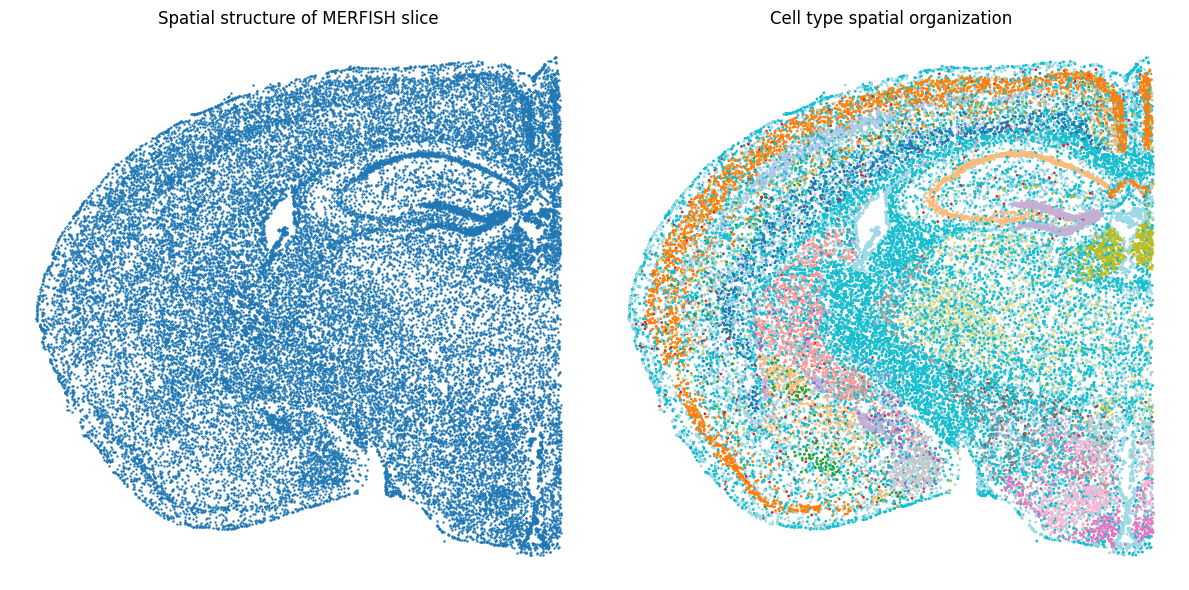

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

coords = adata.obsm['spatial']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6)) 

# Fig.1: MERFISH spatial structure
ax1.scatter(coords[:,0], coords[:,1], s=0.5)
ax1.set_title("Spatial structure of MERFISH slice")
ax1.axis('off')
ax1.invert_yaxis()  # 反转y轴

# Fig.2: Cell type spatial organization
labels = pd.Categorical(adata.obs['cluster_alias'])
sc = ax2.scatter(coords[:,0], coords[:,1], c=labels.codes, s=1, cmap='tab20')
ax2.set_title("Cell type spatial organization")
ax2.axis('off')
ax2.invert_yaxis()

# fig.2 colorbar

#plt.colorbar(sc, ax=ax2, shrink=0.8,orientation = 'horizontal', label='Cell type')

plt.tight_layout()  
plt.show()

In [57]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix


# ==========================================
# Retrieve CCF Anatomy Labels
# ==========================================
# CCF data consists of CSV metadata files, not expression matrices.
# We use get_metadata_dataframe to load the spatial registration mapping.
ccf_metadata = abc_cache.get_metadata_dataframe(
        directory='Zhuang-ABCA-1-CCF',
        file_name='ccf_coordinates'
    )




ccf_coordinates.csv: 100%|██████████| 221M/221M [00:39<00:00, 5.55MMB/s]    


In [58]:
df_ccf = ccf_metadata.copy()
type(df_ccf)

pandas.core.frame.DataFrame

In [59]:
ccf_metadata.head()

,cell_label,x,y,z,parcellation_index
0,182941331246012878296807398333956011710,7.902190,3.048426,0.582962,0
1,221260934538535633595532020856387724686,7.906513,3.145200,0.577602,0
2,22228792606814781533240955623030943708,7.906110,3.182761,0.553731,0
3,272043042552227961220474294517855477150,7.904627,3.131808,0.563525,0
4,110116287883089187971185374239350249328,7.907236,3.230647,0.543048,0


In [60]:
df_ccf.head()

,cell_label,x,y,z,parcellation_index
0,182941331246012878296807398333956011710,7.902190,3.048426,0.582962,0
1,221260934538535633595532020856387724686,7.906513,3.145200,0.577602,0
2,22228792606814781533240955623030943708,7.906110,3.182761,0.553731,0
3,272043042552227961220474294517855477150,7.904627,3.131808,0.563525,0
4,110116287883089187971185374239350249328,7.907236,3.230647,0.543048,0


In [61]:
print("真正的列名列表:", df_ccf.columns.tolist())

真正的列名列表: ['cell_label', 'x', 'y', 'z', 'parcellation_index']


In [62]:
#print(type(adata.obs.index[0]))

#print(type(df_ccf.index[0]))

In [63]:
#set1 = set(adata.obs.index)
""" set1 = set(target_cells_str)
set2 = set(df_ccf.index)

print("Overlap:", len(set1 & set2)) """

' set1 = set(target_cells_str)\nset2 = set(df_ccf.index)\n\nprint("Overlap:", len(set1 & set2)) '

In [64]:
""" print(repr(adata.obs.index[:10]))
print(repr(target_cells_str[:10]))
print(repr(df_ccf.index[:10]))
print(matched_ccf.index[:10]) """

' print(repr(adata.obs.index[:10]))\nprint(repr(target_cells_str[:10]))\nprint(repr(df_ccf.index[:10]))\nprint(matched_ccf.index[:10]) '

In [65]:
""" print(len(set(df_ccf.index) & set(target_cells_str))) """

' print(len(set(df_ccf.index) & set(target_cells_str))) '

In [66]:
""" print("NaN ratio:", matched_ccf['parcellation_index'].isna().mean())
print("valid rows:", matched_ccf['parcellation_index'].notna().sum())
print("valid rows:", adata.obs['ccf_parcellation'].notna().sum()) """

' print("NaN ratio:", matched_ccf[\'parcellation_index\'].isna().mean())\nprint("valid rows:", matched_ccf[\'parcellation_index\'].notna().sum())\nprint("valid rows:", adata.obs[\'ccf_parcellation\'].notna().sum()) '

In [67]:
#adata.obs[['ccf_parcellation']].isna().mean()

In [68]:
#""" print((adata.obs['ccf_parcellation'] == adata.obs['ccf_parcellation']).head(20)) """

In [69]:
""" print(adata.obs[['ccf_parcellation']].iloc[:20])
print(df_ccf['parcellation_index'].iloc[:20]) """

" print(adata.obs[['ccf_parcellation']].iloc[:20])\nprint(df_ccf['parcellation_index'].iloc[:20]) "

In [70]:
""" adata.obs.columns """

' adata.obs.columns '

In [71]:
""" print(adata.obs['ccf_parcellation'].unique()[:10]) """

" print(adata.obs['ccf_parcellation'].unique()[:10]) "

In [72]:
import pandas as pd
import scanpy as sc

# 强制将 target_cells 转为字符串列表
target_cells_str = [str(i) for i in target_cells]

# 核心修正：将 cell_label 列设为索引
if 'cell_label' in df_ccf.columns:
    df_ccf = df_ccf.set_index('cell_label')
    df_ccf.index = df_ccf.index.astype(str)
else:
    print("ERROR: No 'cell_label' column found in CCF metadata.")
    print("Available columns:", df_ccf.columns.tolist())
    raise ValueError("Cannot proceed without cell_label")

# 打印可用的CCF列，供后续使用
print("Available CCF columns after setting index:", df_ccf.columns.tolist())

# Reindex CCF metadata to match MERFISH cell labels
matched_ccf = df_ccf.reindex(target_cells_str)

# ✓ 检查重新索引的成功率
null_fraction = matched_ccf.isna().mean()
print(f"\nReindex validation:")
print(f"  Rows with any NaN: {null_fraction.max():.1%}")
print(f"  Expected: should be low (near 0) if alignment is successful")

# 提取并注入所有需要的CCF列
ccf_columns_to_inject = []
for col in ['parcellation_index', 'ccf_region_id', 'subregion', 'region_name']:
    if col in df_ccf.columns:
        ccf_columns_to_inject.append(col)

if not ccf_columns_to_inject:
    print("WARNING: No expected CCF columns found!")
    print("Available:", df_ccf.columns.tolist())
else:
    print(f"\nInjecting CCF columns: {ccf_columns_to_inject}")
    for col in ccf_columns_to_inject:
        adata.obs[f'ccf_{col}'] = matched_ccf[col].to_numpy()

# 输出注入结果摘要
print("\nCCF data injection complete.")
print(f"adata.obs now contains these CCF-related columns:")
for col in adata.obs.columns:
    if 'ccf' in col.lower():
        print(f"  - {col}: {adata.obs[col].dtype}, null count: {adata.obs[col].isna().sum()}")


Available CCF columns after setting index: ['x', 'y', 'z', 'parcellation_index']

Reindex validation:
  Rows with any NaN: 1.2%
  Expected: should be low (near 0) if alignment is successful

Injecting CCF columns: ['parcellation_index']

CCF data injection complete.
adata.obs now contains these CCF-related columns:
  - ccf_parcellation_index: float64, null count: 432


In [73]:
matched_ccf.head(10)

,x,y,z,parcellation_index
cell_label,,,,
247976677407794870437144677714829459713,NaN,NaN,NaN,NaN
168655970434508722627007022423841385743,NaN,NaN,NaN,NaN
306182408260920364328788238077659872267,NaN,NaN,NaN,NaN
323418747114703574223827093207552818826,NaN,NaN,NaN,NaN
150648836575778299138347196129291396742,NaN,NaN,NaN,NaN
166945246504850306202259938581288038809,NaN,NaN,NaN,NaN
291735266733040418568326025457648956415,NaN,NaN,NaN,NaN
173437065360394073290961758992490757818,NaN,NaN,NaN,NaN
233020733262638875138340556414733481992,NaN,NaN,NaN,NaN


In [74]:
adata.obs.head(10)


,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id,ccf_parcellation_index
cell_label,,,,,,,,,,,,,,
247976677407794870437144677714829459713,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.897555,2.566162,6.757411,0.967143,0.770255,True,b9bb02ea-7010-4c88-87b4-98f5821196b7,NaN
168655970434508722627007022423841385743,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,329,5.896700,2.367992,6.757411,0.999981,0.813040,True,de92920d-330a-44e0-ae02-447b29f86df3,NaN
306182408260920364328788238077659872267,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,328,5.903615,2.375955,6.757411,0.999961,0.911270,True,bc0e89db-a5ad-420d-a3d0-30d51d3e0ef1,NaN
323418747114703574223827093207552818826,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.891746,2.252074,6.757411,0.934844,0.849401,True,69313d20-57eb-4a12-af02-cddd45aeebc9,NaN
150648836575778299138347196129291396742,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14859,5.902247,2.198086,6.757411,0.999988,0.592299,True,3b391d3d-cff0-4dc7-9df0-c4779ac2a7c7,NaN
166945246504850306202259938581288038809,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.889298,2.083881,6.757411,0.888093,0.713157,True,29978f3f-d63f-46b7-a322-2e93a77234ab,NaN
291735266733040418568326025457648956415,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5231,5.892826,2.118437,6.757411,0.999956,0.791798,True,2e9c4ed0-4e8c-46e9-84d7-19199aba617e,NaN
173437065360394073290961758992490757818,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5252,5.897400,1.998140,6.757411,0.999949,0.518648,True,45f9d8ba-8f71-4a05-a7ff-7ff34bc10aaa,NaN
233020733262638875138340556414733481992,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5216,5.895909,1.956279,6.757411,0.994187,0.695191,True,740eb47b-9cc6-4984-8210-6f2788332db9,NaN


In [75]:
# ==========================================
# Phase 2: Dimensionality Reduction
# ==========================================
# Standard scaling and PCA to create the feature distance space for HMRF.

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')

print("Phase 2 Complete: PCA features generated.")

# ==========================================
# Phase 3 & 4: Distance Graph & AW Weights
# ==========================================
# We build physical edges and weight them by anatomical boundaries.

k_neighbors = 8
alpha_penalty = 0.2

# Build the spatial graph using native MERFISH coordinates
spatial_coords = adata.obsm['spatial'][:, :2]
knn_model = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='ball_tree').fit(spatial_coords)
distances, indices = knn_model.kneighbors(spatial_coords)

# ✓ Extract the CCF anatomy labels with fallback logic
ccf_label_column = None
for col in ['ccf_ccf_region_id', 'ccf_region_id', 'ccf_parcellation_index', 'ccf_parcellation']:
    if col in adata.obs.columns:
        ccf_label_column = col
        break

if ccf_label_column is None:
    raise ValueError(
        f"Cannot find anatomy label column. Available columns: {[c for c in adata.obs.columns if 'ccf' in c.lower()]}"
    )

print(f"Using anatomy labels from: {ccf_label_column}")
anatomy_labels = adata.obs[ccf_label_column].values

# Validate that anatomy labels are not all NaN
if pd.isna(anatomy_labels).all():
    raise ValueError(f"All values in {ccf_label_column} are NaN. CCF alignment may have failed.")

rows = []
cols = []
weights = []

# Construct the Anatomy-Weighted Adjacency Matrix
for i in range(len(indices)):
    for j_idx in range(1, k_neighbors+1):
        neighbor_i = indices[i, j_idx]
        
        rows.append(i)
        cols.append(neighbor_i)

        # AW Logic: Check if physical neighbors belong to the same official brain region
        # Handle NaN values gracefully
        if pd.isna(anatomy_labels[i]) or pd.isna(anatomy_labels[neighbor_i]):
            weights.append(alpha_penalty)  # Use penalty for unknown regions
        elif anatomy_labels[i] == anatomy_labels[neighbor_i]:
            weights.append(1.0)
        else:
            weights.append(alpha_penalty)

W_aw = csr_matrix((weights, (rows, cols)), shape=(len(spatial_coords), len(spatial_coords)))

print(f"Phase 3 & 4 Complete: AW-Adjacency Matrix built.")
print(f"Matrix shape: {W_aw.shape}, Non-zero edges: {W_aw.nnz}")


Phase 2 Complete: PCA features generated.
Using anatomy labels from: ccf_parcellation_index
Phase 3 & 4 Complete: AW-Adjacency Matrix built.
Matrix shape: (37068, 37068), Non-zero edges: 296544


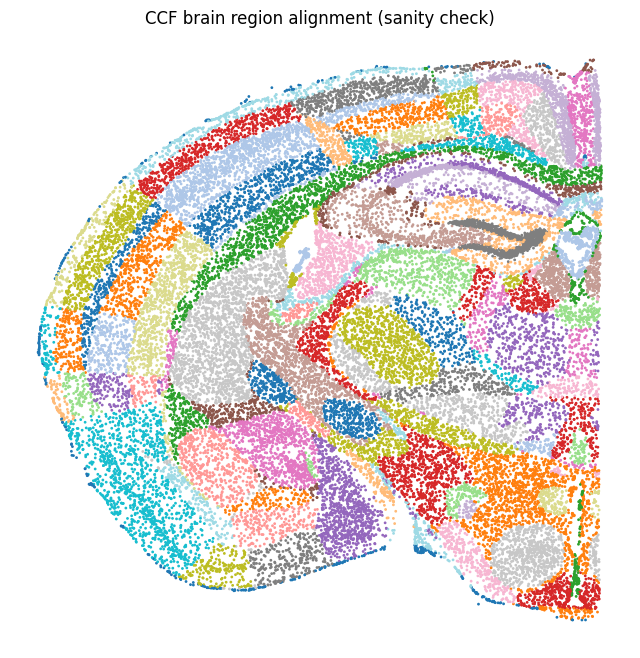

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 取数据
# =========================
coords = adata.obsm['spatial'][:, :2]   # 2D slice

labels_raw = adata.obs['ccf_parcellation_index']  # 或你的实际列名

# =========================
# 2. 去掉 NaN（非常关键）
# =========================
mask = labels_raw.notna()

coords_valid = coords[mask.values]
labels_valid = labels_raw[mask].astype(str)

# =========================
# 3. 稳定 categorical encoding
# =========================
labels_cat = pd.Categorical(labels_valid)
color_idx = labels_cat.codes

# =========================
# 4. plot
# =========================
plt.figure(figsize=(8, 8))

plt.scatter(
    coords_valid[:, 0],
    coords_valid[:, 1],
    c=color_idx,
    s=1,
    cmap='tab20'
)

plt.title("CCF brain region alignment (sanity check)")
plt.axis('off')
plt.gca().invert_yaxis()

plt.show()


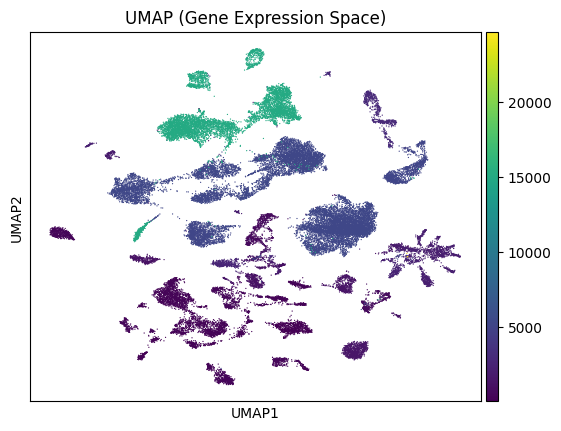

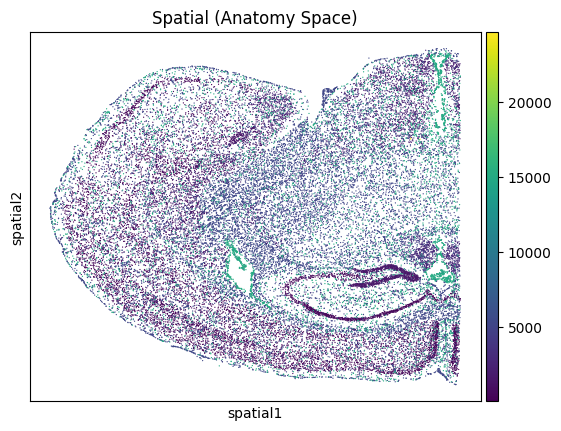

In [77]:
# --- 笔记本 1 的后续标准动作 ---

# 1. 数据缩放
sc.pp.scale(adata, max_value=10)

# 2. PCA 降维 (这是 Notebook 2 算特征距离的输入)
sc.tl.pca(adata, svd_solver='arpack')

# 3. UMAP 可视化 (用来验证基因聚类和空间聚类是否一致)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata)

# 4. 对比图：左边是 UMAP，右边是空间位置
sc.pl.umap(adata, color='cluster_alias', title="UMAP (Gene Expression Space)")
sc.pl.embedding(adata, basis='spatial', color='cluster_alias', title="Spatial (Anatomy Space)")

# 5. 保存结果供 Notebook 2 使用
adata.write('../data/Zhuang_1080_embedded.h5ad')